In [1]:
import numpy as np
from pathlib import Path
import matplotlib as mpl
from matplotlib import pyplot as plt

import xarray as xr
import warnings
import pandas as pd
import geopandas as gpd

import cartopy.crs as ccrs
from cartopy.crs import Geodetic, Stereographic, PlateCarree
import cartopy
from shapely.geometry import Polygon

warnings.simplefilter("ignore")

In [134]:
# Plot relevant parameters
suptitle_size = 20
title_size = 16
mapsize = (16, 8)
extent = (2.5, 27.5, 52, 62)
lon_mid = np.mean(extent[:2])
lat_mid = np.mean(extent[2:])
map_projection = Stereographic(central_longitude=lon_mid, central_latitude=lat_mid,)
def basemap(ax):
    ax.set_extent(extent, PlateCarree())
    ax.add_feature(cartopy.feature.LAND)
    ax.add_feature(cartopy.feature.COASTLINE)
    ax.gridlines(draw_labels=["left", "bottom"], y_inline=False,)
    return ax

In [150]:
gpd.points_from_xy(location_lon, location_lat, crs=ccrs.Geodetic())

NameError: name 'location_lon' is not defined

In [154]:
def make_sample_point(
        location_name, location_id, location_id_old, sample_kind, genomic_data, order, sea, location_lat, location_lon
        ):
        return dict(
                location_name=location_name, 
                location_id=location_id,
                location_id_old=location_id_old,
                sample_kind=sample_kind,
                genomic_data=genomic_data,
                order=order,
                sea=sea,
                geometry=gpd.points_from_xy([location_lon], [location_lat], crs=ccrs.Geodetic())[0],
        )

In [179]:
sample_test = [
        make_sample_point('KB03', 'KB03', 'KB03', 'real', True, 11, 'baltic', 54.692, 10.1035),
        make_sample_point('SW08', 'SW08', 'SW08', 'real', True, 13, 'baltic', 54.413, 11.617),
        make_sample_point('Boknis_Eck', 'BOK', 'BE01', 'real', True, 12, 'baltic', 54.5169, 10.034),
        make_sample_point('Gdynia', 'GDY', 'GD01', 'real', True, 19, 'baltic', 54.5829, 18.6042),
        make_sample_point('IU7_c', 'IU7', 'IU07', 'real', False, 28, 'baltic', 59.489, 21.2021),
        make_sample_point('LL17_c', 'LL17', 'LL17', 'real', False, 27, 'baltic', 59.02, 21.0478),
        make_sample_point('Finland', 'FIN', 'FI01', 'real', True, 29, 'baltic', 59.77, 23.2663),
        make_sample_point('Speicherkoog_moved', 'SK02', 'SK02', 'moved', True, 1, 'northsea', 54.11, 8.5),
        make_sample_point('Wilhelmshaven_moved', 'WH02', 'WH02', 'moved', True, 0, 'northsea', 53.637, 8.15),
        make_sample_point('Kategat01', 'KG01', 'KG01', 'digital', False, 10, 'northsea', 56.35, 11.8),
        make_sample_point('Kategat02', 'KG02', 'KG02', 'digital', False, 9, 'northsea', 57.0, 11.5),
        make_sample_point('Skagerak01', 'SR01', 'SR01', 'digital', False, 7, 'northsea', 58.0, 10.5),
        make_sample_point('Skagerak02', 'SR02', 'SR02', 'digital', False, 5, 'northsea', 57.5, 8.0),
        make_sample_point('JB01', 'JB01', 'JB01', 'digital', False, 4, 'northsea', 56.5, 7.2),
        make_sample_point('DeutscheBucht01', 'DB01', 'DB01', 'digital', False, 3, 'northsea', 55.5, 7.0),
        make_sample_point('DeutscheBucht02', 'DB02', 'DB02', 'digital', False, 2, 'northsea', 54.5, 7.4),
        make_sample_point('BalticPropper01', 'BP01', 'BP01', 'digital', False, 17, 'baltic', 55.5, 17.2),
        make_sample_point('BalticPropper02', 'BP02', 'BP02', 'digital', False, 18, 'baltic', 56.1, 18.5),
        make_sample_point('EG01', 'EG01', 'EG01', 'digital', False, 24, 'baltic', 57.4, 20.2),
        make_sample_point('EG02', 'EG02', 'EG02', 'digital', False, 25, 'baltic', 58.3, 20.6),
        make_sample_point('Skagerak03', 'SR03', 'SR03', 'digital', False, 6, 'northsea', 58.3, 9.3),
        make_sample_point('WG01', 'WG01', 'WG01', 'digital', False, 21, 'baltic', 57.0, 17.4),
        make_sample_point('WG02', 'WG02', 'WG02', 'digital', False, 22, 'baltic', 58.5, 18.5),
        make_sample_point('BalticPropper03', 'BP03', 'BP03', 'digital', False, 20, 'baltic', 55.4, 19.3),
        make_sample_point('BB23', 'BB23', 'BB23', 'real', False, 15, 'baltic', 55.2912, 15.7503),
        make_sample_point('BB36', 'BB36', 'BB36', 'real', True, 16, 'baltic', 54.9589, 15.9981),
        make_sample_point('GB96', 'GB96', 'GB96', 'real', True, 23, 'baltic', 56.9165, 19.5827),
        make_sample_point('H21', 'H21', 'HR21', 'real', True, 14, 'baltic', 54.9433, 13.4914),
        make_sample_point('Speicherkoog', 'SK', 'SK', 'real', True, 1, 'northsea', 54.0929, 8.9487),
        make_sample_point('Wilhelmshaven', 'WH', 'WH', 'real', True, 0, 'northsea', 53.513, 8.149),
]

In [180]:
# Source - https://stackoverflow.com/a/5946359
# Posted by blubb, modified by community. See post 'Timeline' for change history
# Retrieved 2026-06-23, License - CC BY-SA 4.0

ds = sample_test
sample_points = {}
for column in sample_test[0].keys():
  sample_points[column] = list(location[column] for location in sample_test)
gdf_sample_points = gpd.GeoDataFrame(sample_points, crs=ccrs.Geodetic()).sort_values("order")
gdf_sample_points

,location_name,location_id,location_id_old,sample_kind,genomic_data,order,sea,geometry
8,Wilhelmshaven_moved,WH02,WH02,moved,True,0,northsea,POINT (8.15 53.637)
29,Wilhelmshaven,WH,WH,real,True,0,northsea,POINT (8.149 53.513)
28,Speicherkoog,SK,SK,real,True,1,northsea,POINT (8.9487 54.0929)
7,Speicherkoog_moved,SK02,SK02,moved,True,1,northsea,POINT (8.5 54.11)
15,DeutscheBucht02,DB02,DB02,digital,False,2,northsea,POINT (7.4 54.5)
14,DeutscheBucht01,DB01,DB01,digital,False,3,northsea,POINT (7 55.5)
13,JB01,JB01,JB01,digital,False,4,northsea,POINT (7.2 56.5)
12,Skagerak02,SR02,SR02,digital,False,5,northsea,POINT (8 57.5)
20,Skagerak03,SR03,SR03,digital,False,6,northsea,POINT (9.3 58.3)
11,Skagerak01,SR01,SR01,digital,False,7,northsea,POINT (10.5 58)


In [181]:
# define Paths
output_path = Path("/gxfs_work/geomar/smomw597/2025_copepods/output/SamplePoints")
output_sample_points = Path(output_path,"SamplePoints.shp")
output_voronoi_polygons = Path(output_path,"VoronoiPolygons.shp")
output_voronoi_ocean_polygons = Path(output_path,"VoronoiOceanPolygons.shp")

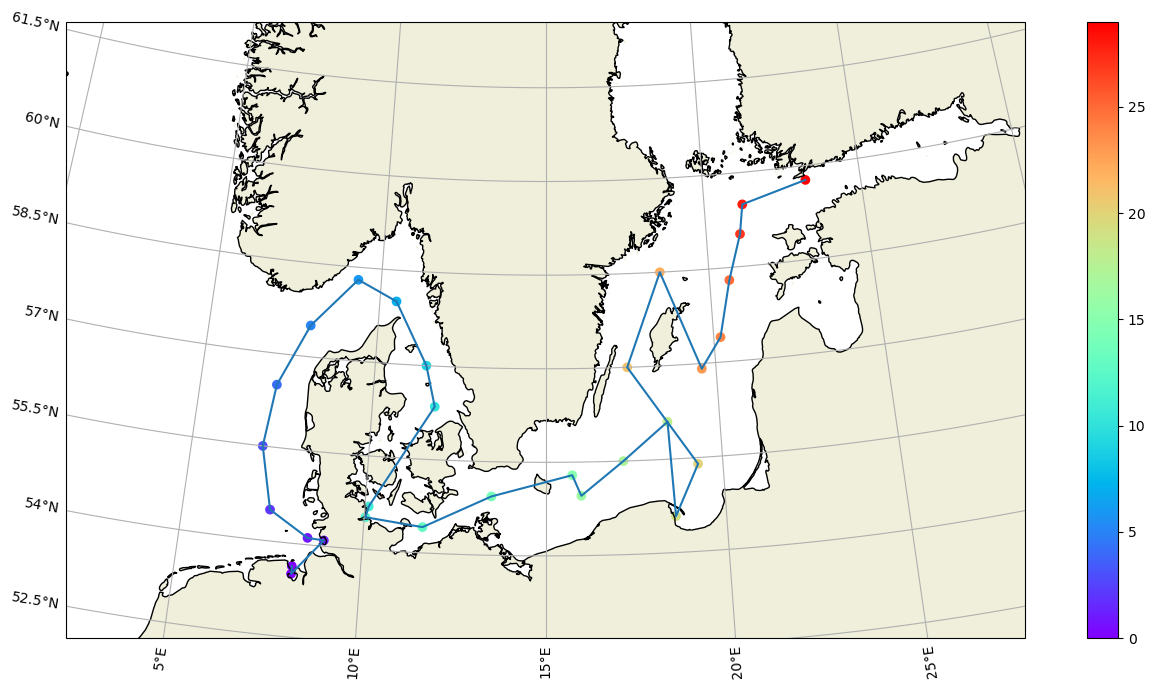

In [182]:
gdf_sample_points_map = gdf_sample_points.to_crs(map_projection)
fig = plt.figure(figsize=mapsize)
ax_map = fig.add_subplot(projection=map_projection)
basemap(ax_map)
gdf_sample_points_map.plot(ax=ax_map, column="order", cmap='rainbow', legend=True)
ax_map.plot(gdf_sample_points_map.geometry.x, gdf_sample_points_map.geometry.y)
plt.show()

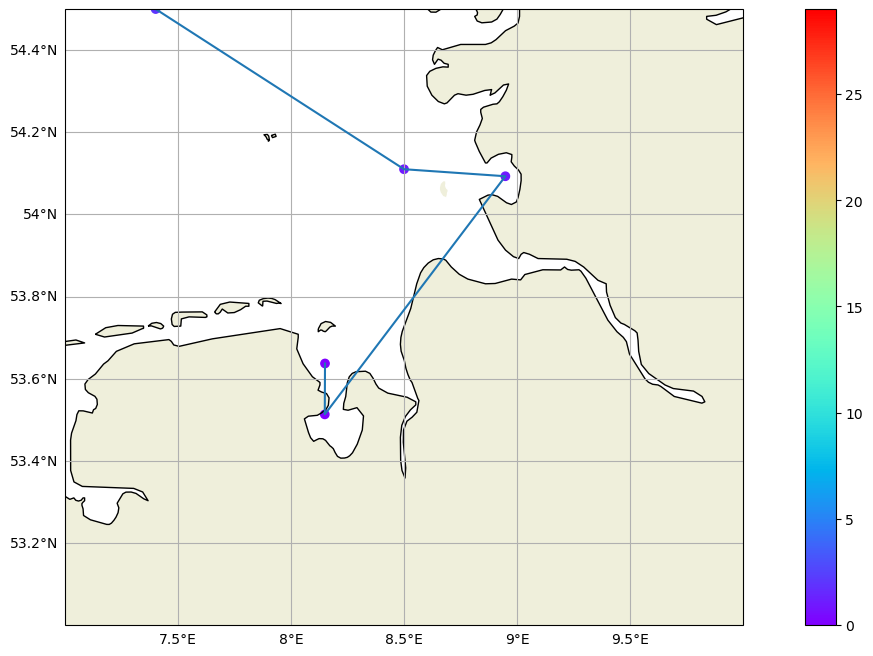

In [183]:
gdf_sample_points_map = gdf_sample_points#.to_crs(map_projection)
fig = plt.figure(figsize=mapsize)
ax_map = fig.add_subplot(projection=ccrs.PlateCarree())
basemap(ax_map)
gdf_sample_points_map.plot(ax=ax_map, column="order", cmap='rainbow', legend=True)
ax_map.plot(gdf_sample_points_map.geometry.x, gdf_sample_points_map.geometry.y)
ax_map.set_extent((7, 10, 53, 54.5))
plt.show()

In [17]:
# Define the the radius of interest around the sample points
centroid = gdf_sample_points.dissolve().centroid.to_crs(Geodetic())
area_of_interest = (
    gpd.GeoDataFrame(
        gdf_sample_points.SampleID,
        geometry=gdf_sample_points.to_crs(
            ccrs.Orthographic(
                # Set the central position of the Projection to the centroid
                central_longitude=centroid.x.values[0], 
                central_latitude=centroid.y.values[0]
                )
            )
        # Set the Bufferdistance to 125 000 metres
        .buffer(distance=1.25e5)
        # Reproject to the map projection
        .to_crs(map_projection)
        )
        # Dissolve the polygons to one single Polygon
        .dissolve()
    )

In [18]:
# Build geodataframe for voronoi polygons
gdf_voronoi = gdf_sample_points.voronoi_polygons()
sample_polygons = { 
    'geometry': gdf_voronoi,
    }
gdf_voronoi = gpd.GeoDataFrame(sample_polygons).to_crs(map_projection)

In [19]:
# Reorder the polygons so that the IDs are correct
gdf_voronoi_polygons = gpd.sjoin(left_df=gdf_voronoi, right_df=gdf_sample_points, how="left", rsuffix="polygon")
gdf_voronoi_polygons.rename(columns={'index_polygon':'index', 'SampleID': 'PolygonID'}, inplace = True)
gdf_voronoi_polygons = gdf_voronoi_polygons.set_index('index').sort_index()

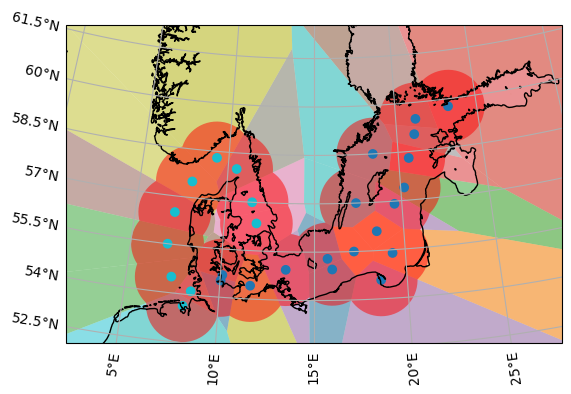

In [21]:
fig = plt.figure()
ax_map = fig.add_subplot(projection=map_projection)
basemap(ax_map)
gdf_voronoi_polygons.plot(ax=ax_map, alpha=0.5, column="PolygonID",)
area_of_interest.plot(ax=ax_map, alpha=0.5, color="r")
# gdf_sample_points.plot(ax=ax_map)
gdf_sample_points.plot(ax=ax_map, column="sea")
plt.show()

In [22]:
gdf_voronoi_clipped = gdf_voronoi_polygons.clip(area_of_interest).sort_index()

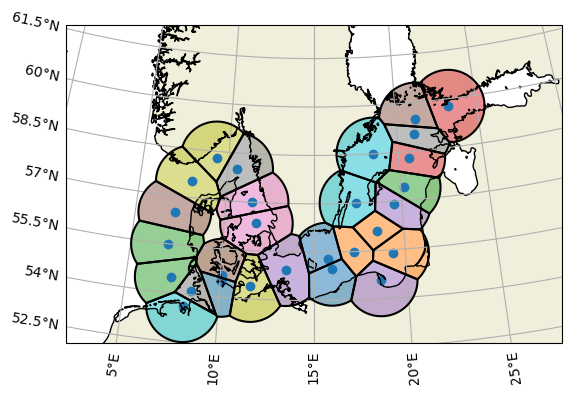

In [23]:
fig = plt.figure()
ax_map = fig.add_subplot(projection=map_projection)
basemap(ax_map)
gdf_voronoi_clipped.plot(ax=ax_map, alpha=0.5, column="PolygonID",)
gdf_voronoi_clipped.boundary.plot(ax=ax_map, color="k",)
gdf_sample_points.plot(ax=ax_map)
map_extent = ax_map.get_extent(crs=map_projection)
plt.show()

In [ ]:
gdf_voronoi_clipped.to_file(output_voronoi_polygons)

In [25]:
ocean_50m = cartopy.feature.NaturalEarthFeature('physical', 'ocean', '50m')

for i, poly in enumerate(ocean_50m.intersecting_geometries(map_extent)):
    if i == 0:
        polygon = list([poly])
    else:
        polygon.append(poly)
ocean_poly = gpd.GeoDataFrame({'geometry':polygon}, crs=Geodetic()).to_crs(map_projection).clip(area_of_interest)
ocean_poly
gdf_voronoi_ocean = gdf_voronoi_clipped.clip(ocean_poly).sort_index()
# devide by 10^6 because the unit we need is km^2 while th output unit is m^2
gdf_voronoi_ocean['area'] = gdf_voronoi_ocean.clip(ocean_poly).sort_index().area/1e6
gdf_voronoi_ocean

,geometry,Sample,PolygonID,SampleID_old,SampleKind,GenomicData,order,sea,area
index,,,,,,,,,
0,"MULTIPOLYGON (((-405759.252 -184049.375, -4029...",KB03,KB03,KB03,real,True,11,baltic,7131.761408
1,"POLYGON ((-254071.962 -228942.318, -255090.543...",SW08,SW08,SW08,real,True,13,baltic,9176.559548
2,"POLYGON ((-269963.882 -270316.108, -273132.878...",Boknis_Eck,BOK,BE01,real,True,12,baltic,930.554160
3,"POLYGON ((204618.036 -196163.794, 316799.647 -...",Gdynia,GDY,GD01,real,True,19,baltic,6573.512733
4,"POLYGON ((242882.202 275118.952, 225673.069 29...",IU7_c,IU7,IU07,real,False,28,baltic,21011.796150
5,"POLYGON ((428608.732 260926.853, 433648.978 25...",LL17_c,LL17,LL17,real,False,27,baltic,12120.685177
6,"POLYGON ((376387.286 395614.452, 382180.529 39...",Finland,FIN,FI01,real,True,29,baltic,18398.696027
7,"POLYGON ((-479346.261 -304535.461, -414663.882...",Speicherkoog_moved,SK,SK02,moved,True,1,northsea,5747.241367
8,"POLYGON ((-424311.271 -335177.235, -426399.783...",Wilhelmshaven_moved,WH,WH02,moved,True,0,northsea,5212.630008


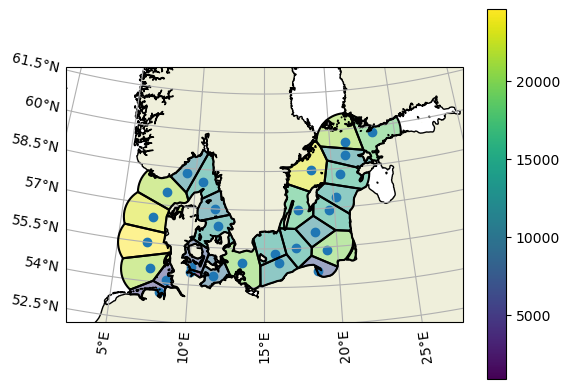

In [26]:
fig = plt.figure()
ax_map = fig.add_subplot(projection=map_projection)
basemap(ax_map)
gdf_voronoi_ocean.plot(ax=ax_map, alpha=0.5, column="area", legend=True)
gdf_voronoi_ocean.boundary.plot(ax=ax_map, color="k",)
gdf_sample_points.plot(ax=ax_map)
plt.show()

In [ ]:
gdf_voronoi_ocean.to_file(output_voronoi_ocean_polygons)

In [ ]:
gdf_sample_points.to_file(output_sample_points)

In [ ]:
data_path_static_files = Path("/gxfs_work/geomar/smomw122/bsh_operationalmodel_data")
data_path_static_fine = data_path_static_files / "static_file_fine"
data_path_static_coarse = data_path_static_files / "static_file_coarse"
h0_file_fine = data_path_static_fine / "H0_file_fine.nc"
h0_file_coarse = data_path_static_coarse / "H0_file_coarse.nc"
mask_land_fine = xr.open_dataset(h0_file_fine).H0.isnull()
mask_land_coarse = xr.open_dataset(h0_file_coarse).H0.isnull()

In [78]:
from shapely.geometry import Polygon
finebox = Polygon([
    (mask_land_fine.lon.min().values, mask_land_fine.lat.min().values),
    (mask_land_fine.lon.max().values, mask_land_fine.lat.min().values),
    (mask_land_fine.lon.max().values, mask_land_fine.lat.max().values),
    (mask_land_fine.lon.min().values, mask_land_fine.lat.max().values),
    (mask_land_fine.lon.min().values, mask_land_fine.lat.min().values),
    ])

In [79]:
coarsebox = Polygon([
    (mask_land_coarse.lon.min().values, mask_land_coarse.lat.min().values),
    (mask_land_coarse.lon.max().values, mask_land_coarse.lat.min().values),
    (mask_land_coarse.lon.max().values, mask_land_coarse.lat.max().values),
    (mask_land_coarse.lon.min().values, mask_land_coarse.lat.max().values),
    (mask_land_coarse.lon.min().values, mask_land_coarse.lat.min().values),
    ])

In [ ]:
gdf_land_fine = gpd.GeoDataFrame(
    mask_land_fine.to_dataframe().reset_index().H0,
    geometry=gpd.points_from_xy(
        mask_land_fine.to_dataframe().reset_index().lon,
        mask_land_fine.to_dataframe().reset_index().lat,
        crs=Geodetic()
        )
    )
# mask_land_fine.to_dataframe().reset_index()

In [ ]:
gdf_land_coarse = gpd.GeoDataFrame(
    mask_land_coarse.to_dataframe().reset_index().H0,
    geometry=gpd.points_from_xy(
        mask_land_coarse.to_dataframe().reset_index().lon,
        mask_land_coarse.to_dataframe().reset_index().lat,
        crs=Geodetic()
        ).difference(finebox)
    )
# mask_land_fine.to_dataframe().reset_index()
# gdf_land_coarse = gdf_land_coarse.difference(finebox)


In [83]:
gdf_land = pd.concat([gdf_land_coarse,gdf_land_fine])

In [84]:
gdf_land = gdf_land.clip(gdf_voronoi_clipped.to_crs(Geodetic()))

In [21]:
voronoi_outlines_polygon = gdf_voronoi_clipped.to_crs(Geodetic()).polygonize()

In [30]:
gdf_land

,H0,geometry
238543,True,POINT (11.7708 53.2958)
238545,True,POINT (11.7986 53.2958)
238541,True,POINT (11.7431 53.2958)
238534,True,POINT (11.6458 53.2958)
237923,True,POINT (11.9097 53.3042)
...,...,...
69758,True,POINT (13.125 57.475)
69344,True,POINT (13.125 57.525)
68930,True,POINT (13.125 57.575)
68516,True,POINT (13.125 57.625)


In [31]:
gdf_land_raster = gpd.GeoDataFrame(
    gdf_land.H0,
    geometry=gdf_land.voronoi_polygons(
        extend_to=voronoi_outlines_polygon[0]
        )
)#.to_crs(Geodetic())

<Axes: >

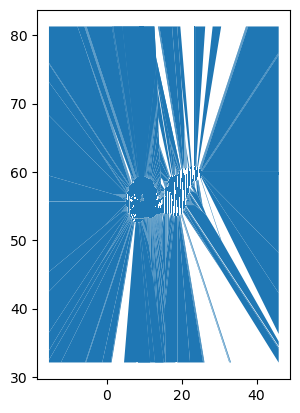

In [29]:
gdf_land_raster.plot()

<Axes: >

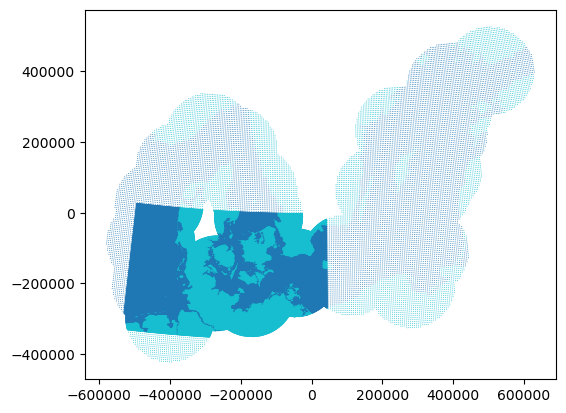

In [396]:
gpd.GeoDataFrame(
    gdf_land.H0,
    geometry=gdf_land.to_crs(
            ccrs.Orthographic(
                # Set the central position of the Projection to the centroid
                central_longitude=centroid.x.values[0], 
                central_latitude=centroid.y.values[0]
                )
            ).buffer(distance=1.25e3)
).plot(column="H0")

In [232]:
gdf_test_raster = gdf_land_raster.clip(gdf_voronoi_clipped.to_crs(Geodetic()))

<Axes: >

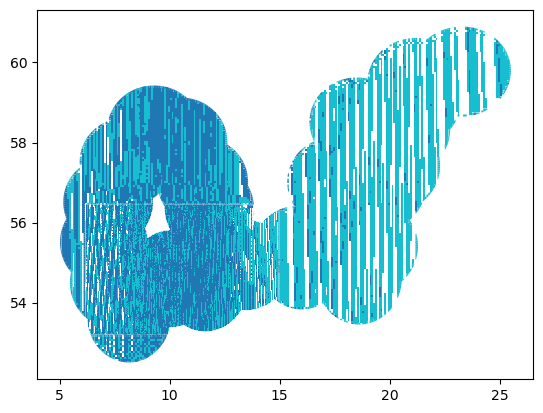

In [252]:
gdf_test_raster.plot(column="H0")

<Axes: >

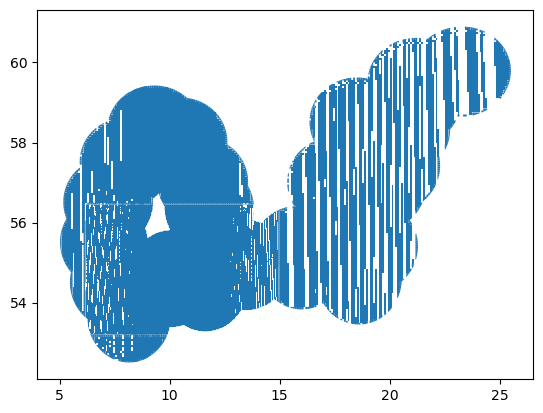

In [199]:
gdf_test_raster.plot()#.where(gdf_test_raster.H0==False).dropna().plot()

KeyboardInterrupt: 

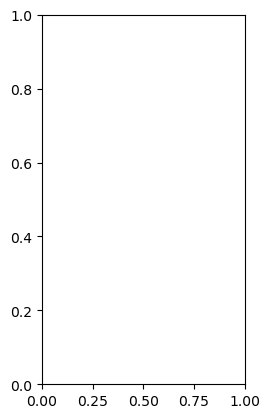

In [149]:
gdf_land_raster.where(gdf_land_raster.H0==True).plot()#.intersects(gdf_voronoi_clipped)
# gdf_voronoi_clipped.intersection(gdf_land_raster)

<Axes: >

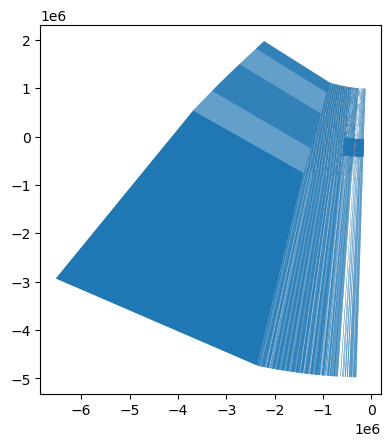

In [30]:
gdf_land_raster.where(gdf_land_raster.H0==True).dropna().plot()

In [267]:
gdf_voronoi_clipped.clip(mask_land_fine)

TypeError: If 'mask' is list-like, it must have four values (minx, miny, maxx, maxy)

In [32]:
df = ds_trajectories.get(["lat","lon"]).to_dataframe().reset_index().dropna()
print(df.size/1e9)

NameError: name 'ds_trajectories' is not defined

In [ ]:
gdf_traj = gpd.GeoDataFrame(
    df.trajectory,
    geometry=gpd.points_from_xy(df.lon, df.lat, crs=Geodetic())
    )

In [22]:
nrows_half = np.round(len(gdf_traj)/2).astype("int")

In [23]:
gdf_projected = gdf_traj[:nrows_half].to_crs(map_projection)
print("projected")
gdf_projected = gpd.sjoin(left_df=gdf_projected, right_df=gdf_voronoi, how="left", rsuffix="polygon")
print("joined")
gdf_projected_second = gdf_traj[nrows_half:].to_crs(map_projection)
print("projected")
gdf_projected_second = gpd.sjoin(left_df=gdf_projected_second, right_df=gdf_voronoi, how="left", rsuffix="polygon")
print("joined")

projected
joined
projected
joined


In [37]:
gdf_projected = pd.concat([gdf_projected, gdf_projected_second])

NameError: name 'gdf_projected' is not defined

NameError: name 'gdf_projected' is not defined

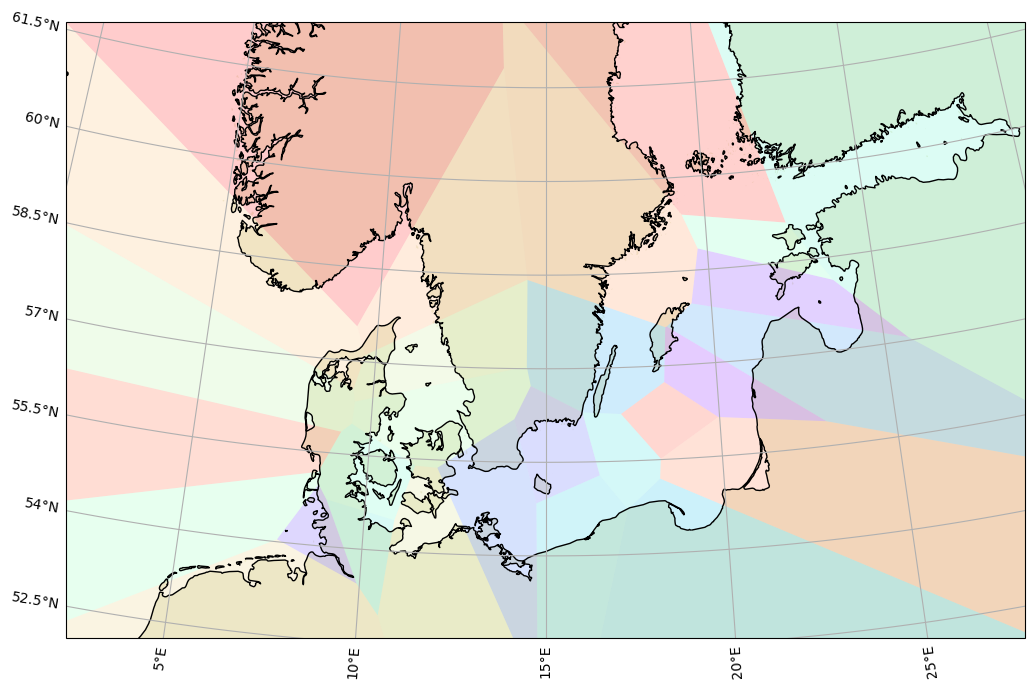

In [36]:
fig = plt.figure(figsize=mapsize)
ax_map = fig.add_subplot(projection=map_projection)
basemap(ax_map)
gdf_voronoi.to_crs(map_projection).plot(ax=ax_map,alpha=0.2, column="SampleID", cmap="rainbow")
gdf_projected[::24*400].plot(ax=ax_map, column="SampleID", cmap="rainbow", s=1)
gdf_voronoi.boundary.to_crs(map_projection).plot(ax=ax_map, color="k",)
gdf_sample_points.plot(ax=ax_map, column="SampleKind", legend=True, )
plt.show()